In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [3]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
'dog', 'frog', 'horse', 'ship', 'truck']


# Load dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

In [4]:
print("Index 0 in label array:", y_train[0], "->", class_names[int(y_train[0])])
print("Index 3 in label array:", y_train[3], "->", class_names[int(y_train[3])])
print("Example: if y_train[3] = 2, that means -> bird")

Index 0 in label array: [6] -> frog
Index 3 in label array: [4] -> deer
Example: if y_train[3] = 2, that means -> bird


C:\Users\DIMPLE MUNDHRA\AppData\Local\Temp\ipykernel_20080\3973859009.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print("Index 0 in label array:", y_train[0], "->", class_names[int(y_train[0])])
C:\Users\DIMPLE MUNDHRA\AppData\Local\Temp\ipykernel_20080\3973859009.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print("Index 3 in label array:", y_train[3], "->", class_names[int(y_train[3])])


In [5]:
x_train = x_train / 255.0
x_test = x_test / 255.0

C:\Users\DIMPLE MUNDHRA\AppData\Local\Temp\ipykernel_20080\2537669831.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(f"Label: {class_names[int(y_train[3])]}")


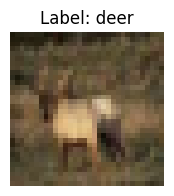

In [6]:
plt.figure(figsize=(2,2))
plt.imshow(x_train[3])
plt.title(f"Label: {class_names[int(y_train[3])]}")
plt.axis("off")
plt.show()

In [7]:
# Data Augmentation
datagen = ImageDataGenerator(
rotation_range=20,
width_shift_range=0.1,
height_shift_range=0.1,
horizontal_flip=True
)
datagen.fit(x_train)

In [9]:
# CNN Model
model = models.Sequential([
layers.Conv2D(32, (3,3), activation='relu', input_shape=(32, 32, 3)),
layers.MaxPooling2D((2,2)),


layers.Conv2D(64, (3,3), activation='relu'),
layers.MaxPooling2D((2,2)),


layers.Conv2D(64, (3,3), activation='relu'),
layers.Flatten(),
layers.Dense(64, activation='relu'),
layers.Dense(10, activation='softmax')
])

In [10]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.compile(optimizer='adam',
loss='sparse_categorical_crossentropy',
metrics=['accuracy'])

In [12]:
# Train
epochs = 10
history = model.fit(datagen.flow(x_train, y_train, batch_size=64),
epochs=epochs,
validation_data=(x_test, y_test))

Epoch 1/10
  1/782 ━━━━━━━━━━━━━━━━━━━━ 22:50 2s/step - accuracy: 0.0469 - loss: 2.2993

c:\Users\DIMPLE MUNDHRA\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


782/782 ━━━━━━━━━━━━━━━━━━━━ 17s 20ms/step - accuracy: 0.2942 - loss: 1.9039 - val_accuracy: 0.4879 - val_loss: 1.4140
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 19s 24ms/step - accuracy: 0.4848 - loss: 1.4212 - val_accuracy: 0.5637 - val_loss: 1.2259
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 21s 26ms/step - accuracy: 0.5427 - loss: 1.2879 - val_accuracy: 0.5700 - val_loss: 1.2385
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 20s 25ms/step - accuracy: 0.5662 - loss: 1.2172 - val_accuracy: 0.5834 - val_loss: 1.2157
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 20s 26ms/step - accuracy: 0.5908 - loss: 1.1538 - val_accuracy: 0.6285 - val_loss: 1.0536
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 18s 23ms/step - accuracy: 0.6109 - loss: 1.0999 - val_accuracy: 0.6304 - val_loss: 1.0555
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - accuracy: 0.6211 - loss: 1.0668 - val_accuracy: 0.6737 - val_loss: 0.9365
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 18s 22ms/step - accuracy: 0.6376 - loss: 1.0240 - val_accurac

In [13]:
# Evaluate
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"\nFinal Test Accuracy: {test_acc:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7002 - loss: 0.8379

Final Test Accuracy: 0.6974


In [14]:
# Predictions
pred = model.predict(x_test)
y_pred = np.argmax(pred, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


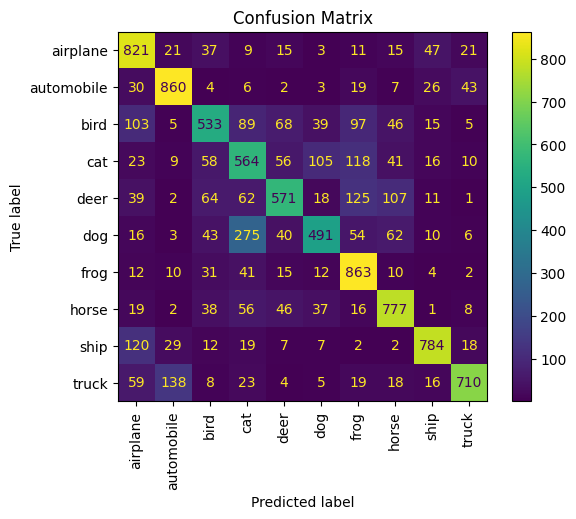

In [15]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
cm_display.plot(xticks_rotation='vertical')
plt.title("Confusion Matrix")
plt.show()